<a href="https://colab.research.google.com/github/vvrgit/ReinforcementLearningCourse/blob/main/MDP_Formulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

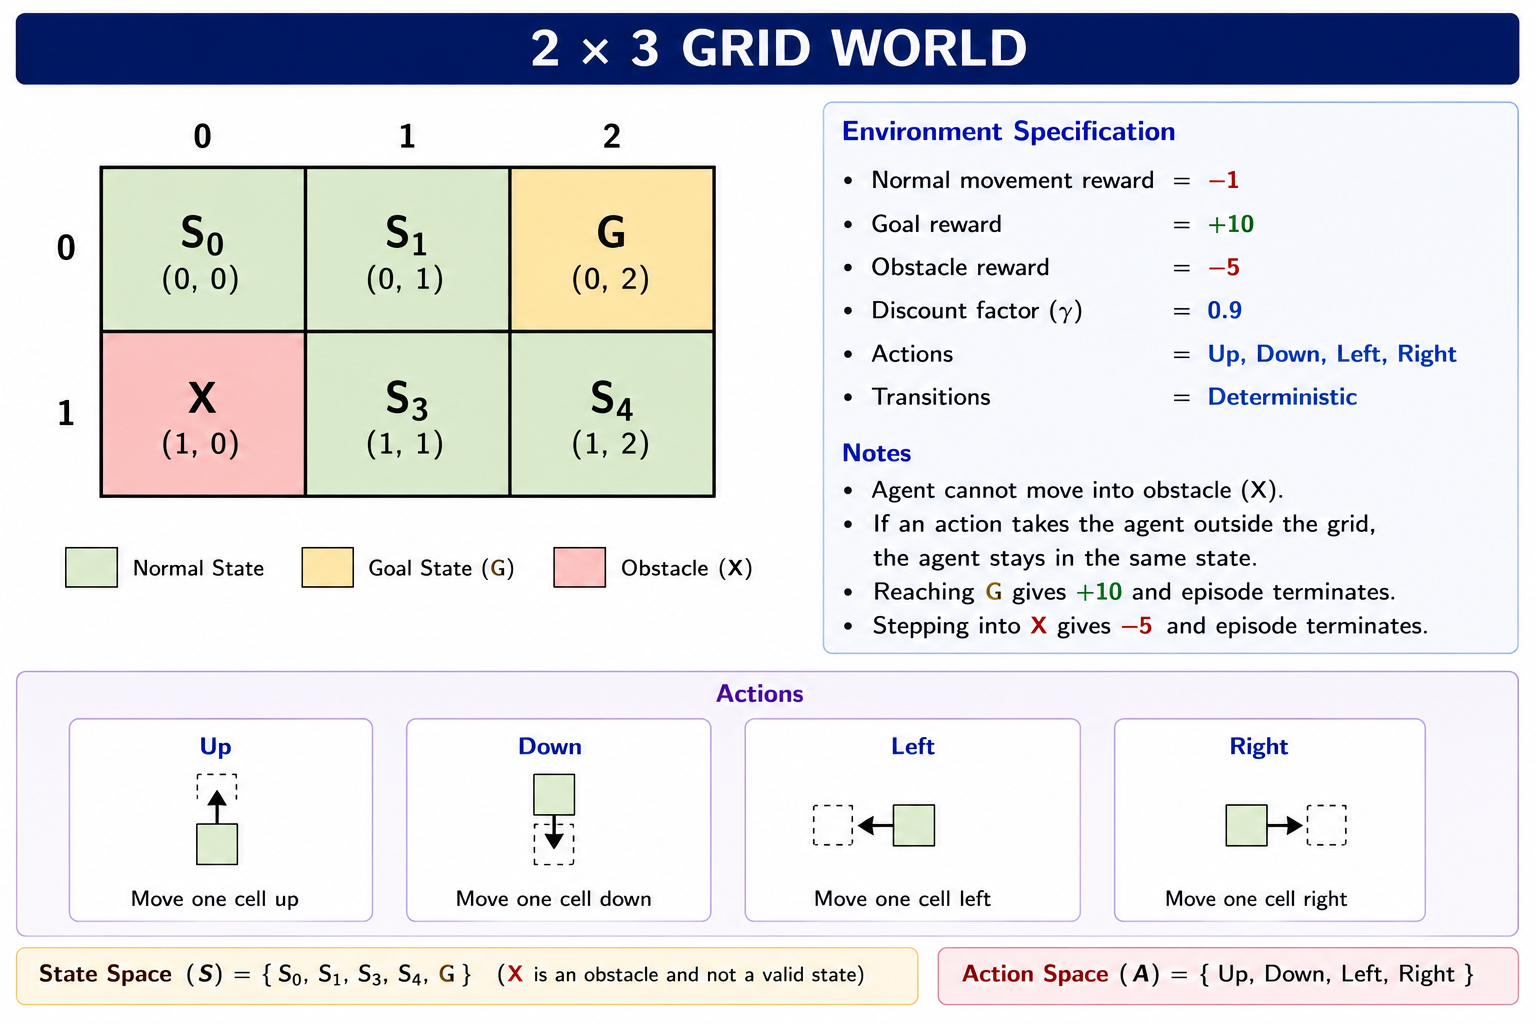

# **Deterministic Environment**

# **States**

In [1]:
def env_state():
  states=["S0","S1","S2","S3","S4","G"]
  return states

In [2]:
env_state()

['S0', 'S1', 'S2', 'S3', 'S4', 'G']

# **Actions**

In [3]:
def env_actions():
  actions=["up","down","left","Right"]
  return actions

In [4]:
env_actions()

['up', 'down', 'left', 'Right']

# **Rewards**

In [5]:
def env_reward():
  reward={
    "move":-0.5,
    "goal":100,
    "obs":-2
  }
  return reward

In [6]:
reward_value=env_reward()
print(reward_value)

{'move': -0.5, 'goal': 100, 'obs': -2}


# **Discount Factor**

In [7]:
def env_df():
  gama=0.9
  return gama

In [8]:
env_df()

0.9

# **Transition**

In [9]:
def env_transition():
  transition={
      ("S0","up"):"S0",
      ("S0","down"):"S0",
      ("S0","left"):"S0",
      ("S0","Right"):"S1",
      ("S1","up"):"S1",
      ("S1","down"):"S3",
      ("S1","left"):"S0",
      ("S1","Right"):"G",
      ("S3","up"):"S1",
      ("S3","down"):"S3",
      ("S3","left"):"S3",
      ("S3","Right"):"S4",
      ("S4","up"):"G",
      ("S4","down"):"S4",
      ("S4","left"):"S3",
      ("S4","Right"):"S4"
  }
  return transition

In [10]:
transitions=env_transition()
print(transitions)

{('S0', 'up'): 'S0', ('S0', 'down'): 'S0', ('S0', 'left'): 'S0', ('S0', 'Right'): 'S1', ('S1', 'up'): 'S1', ('S1', 'down'): 'S3', ('S1', 'left'): 'S0', ('S1', 'Right'): 'G', ('S3', 'up'): 'S1', ('S3', 'down'): 'S3', ('S3', 'left'): 'S3', ('S3', 'Right'): 'S4', ('S4', 'up'): 'G', ('S4', 'down'): 'S4', ('S4', 'left'): 'S3', ('S4', 'Right'): 'S4'}


# **Deterministic Environment Creation**

In [11]:
%%writefile grid_env_det.py

def env_state():
  states=["S0","S1","S2","S3","S4","G"]
  return states

def env_actions():
  actions=["up","down","left","Right"]
  return actions

def env_reward():
  reward={
    "move":-1,
    "goal":10,
    "obs":-5
  }
  return reward

def env_df():
  gama=0.9
  return gama

def env_transition():
  transition={
      ("S0","up"):"S0",
      ("S0","down"):"S0",
      ("S0","left"):"S0",
      ("S0","Right"):"S1",
      ("S1","up"):"S1",
      ("S1","down"):"S3",
      ("S1","left"):"S0",
      ("S1","Right"):"G",
      ("S3","up"):"S1",
      ("S3","down"):"S3",
      ("S3","left"):"S3",
      ("S3","Right"):"S4",
      ("S4","up"):"G",
      ("S4","down"):"S4",
      ("S4","left"):"S3",
      ("S4","Right"):"S4"
  }
  return transition

Overwriting grid_env_det.py


In [12]:
import grid_env_det as env
print(env.env_state())
print(env.env_actions())
print(env.env_reward())
print(env.env_df())
print(env.env_transition())

['S0', 'S1', 'S2', 'S3', 'S4', 'G']
['up', 'down', 'left', 'Right']
{'move': -1, 'goal': 10, 'obs': -5}
0.9
{('S0', 'up'): 'S0', ('S0', 'down'): 'S0', ('S0', 'left'): 'S0', ('S0', 'Right'): 'S1', ('S1', 'up'): 'S1', ('S1', 'down'): 'S3', ('S1', 'left'): 'S0', ('S1', 'Right'): 'G', ('S3', 'up'): 'S1', ('S3', 'down'): 'S3', ('S3', 'left'): 'S3', ('S3', 'Right'): 'S4', ('S4', 'up'): 'G', ('S4', 'down'): 'S4', ('S4', 'left'): 'S3', ('S4', 'Right'): 'S4'}


In [13]:
current_state=input("enter current state")
action=input("enter action up or Right or left or down")
next_state=env.env_transition()[(current_state,action)]
print(next_state)

enter current stateS0
enter action up or Right or left or downup
S0


# **State Value Function**

In [29]:
policy = {
    "S0": "Right",
    "S1": "down",
    "S3": "Right",
    "S4": "up"
}

In [32]:
def state_value_function(start_state,policy):
  state=start_state
  total_reward=0
  count=0
  gama=env.env_df()
  while state!="G":
    action=policy[state]
    next_state=env.env_transition()[(state,action)]
    reward=env.env_reward()
    factor=gama**count
    if next_state=="G":
      total_reward=total_reward+factor*reward["goal"]
    elif next_state=="obs":
      total_reward=total_reward+factor*reward["obs"]
    else:
      total_reward=total_reward+factor*reward["move"]
    state=next_state
    count+=1
  return total_reward

In [33]:
current_state=input("enter current state")
state_value=state_value_function(current_state,policy)
print(f"State value of state {current_state} is {state_value}")

enter current stateS0
State value of state S0 is 4.580000000000001


# **Action Value Function**

In [34]:
policy = {
    "S0": "Right",
    "S1": "down",
    "S3": "Right",
    "S4": "up"
}

In [37]:
def action_value_function(state,action,policy):
  total_reward=0
  count=0
  gama=env.env_df()
  while state!="G":
    factor=gama**count
    next_state=env.env_transition()[(state,action)]
    reward=env.env_reward()
    if next_state=="G":
      total_reward=total_reward+factor*reward["goal"]
    elif next_state=="obs":
      total_reward=total_reward+factor*reward["obs"]
    else:
      total_reward=total_reward+factor*reward["move"]
    state=next_state
    count+=1
    if state != "G":  # Only try to get the next action if not in the goal state
      action=policy[state]
  return total_reward

In [38]:
current_state=input("enter current state")
current_action=input("enter action at current state")
action_value=action_value_function(current_state,current_action,policy)
print(f"Action value of state {current_state} is {action_value}")

enter current stateS0
enter action at current stateup
Action value of state S0 is 3.122


# **State Value Function Using Bellman Equation**